# Exports of livestock equivalent products (head of livestock)
Source: Statistical Abstract 2023 version, Table 4.3A: Formal Exports by value ('000 US $), 2018 – 2022

In [1]:
import pandas as pd
import os
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Set up paths
CURRENT_DIR_PATH = os.getcwd()
OUTPUT_DATA_DIR_PATH = os.path.join(CURRENT_DIR_PATH, "output_data")
INPUT_DATA_DIR_PATH = os.path.join(CURRENT_DIR_PATH, "input_data")
LVST_DATA_DIR_PATH = os.path.join(INPUT_DATA_DIR_PATH, "lvst")
GROWTH_RATES_DATA_DIR_PATH = os.path.join(INPUT_DATA_DIR_PATH, "fernando_ndpiv")

In [3]:
# Load lvst exports data
lvst_exports_df = pd.read_csv(os.path.join(LVST_DATA_DIR_PATH, "uganda_exports_animal_related_2018_2022_usd_thousands.csv"))
lvst_exports_df = lvst_exports_df.drop(columns="SITC_code")
lvst_exports_df.head()

,Description,2018,2019,2020,2021,2022
0,Live animals (excl. fish),1543,563,10165,22086,24359
1,Meat and meat preparations,6924,2268,2222,2312,3696
2,Dairy products and bird eggs,74090,70119,76814,88555,118198
3,"Fish, crustaceans, molluscs & prep.",171668,176484,127627,118613,149608


In [4]:
lvst_exports_df_melt = lvst_exports_df.melt(id_vars="Description", value_name="exports_in_thousand_uds", var_name="year")
lvst_exports_df_melt.head()

,Description,year,exports_in_thousand_uds
0,Live animals (excl. fish),2018,1543
1,Meat and meat preparations,2018,6924
2,Dairy products and bird eggs,2018,74090
3,"Fish, crustaceans, molluscs & prep.",2018,171668
4,Live animals (excl. fish),2019,563


In [5]:
lvst_exports_df_pivot = lvst_exports_df_melt.pivot(index="year", columns="Description", values="exports_in_thousand_uds").reset_index()
lvst_exports_df_pivot.columns.name = None
lvst_exports_df_pivot.head()

,year,Dairy products and bird eggs,"Fish, crustaceans, molluscs & prep.",Live animals (excl. fish),Meat and meat preparations
0,2018,74090,171668,1543,6924
1,2019,70119,176484,563,2268
2,2020,76814,127627,10165,2222
3,2021,88555,118613,22086,2312
4,2022,118198,149608,24359,3696


In [6]:
lvst_exports_df_pivot["meat_and_live_animals"] = lvst_exports_df_pivot["Meat and meat preparations"] + \
                                                    lvst_exports_df_pivot["Live animals (excl. fish)"]

lvst_exports_df_pivot = lvst_exports_df_pivot.drop(columns=["Meat and meat preparations", "Live animals (excl. fish)"])
lvst_exports_df_pivot = lvst_exports_df_pivot.rename(columns={
    "Dairy products and bird eggs":  "dairy_products",
    "Fish, crustaceans, molluscs & prep.": "fish_products",
})

lvst_exports_df_pivot.head()


,year,dairy_products,fish_products,meat_and_live_animals
0,2018,74090,171668,8467
1,2019,70119,176484,2831
2,2020,76814,127627,12387
3,2021,88555,118613,24398
4,2022,118198,149608,28055


In [7]:
# Load original uganda data
uga_legacy_df = pd.read_csv(os.path.join(INPUT_DATA_DIR_PATH, "sisepuede_raw_global_inputs_uganda.csv"))
uga_legacy_df.head()

,year,frac_lvst_mm_buffalo_anaerobic_digester,frac_lvst_mm_cattle_dairy_anaerobic_digester,frac_lvst_mm_cattle_nondairy_anaerobic_digester,frac_lvst_mm_chickens_anaerobic_digester,frac_lvst_mm_goats_anaerobic_digester,frac_lvst_mm_horses_anaerobic_digester,frac_lvst_mm_mules_anaerobic_digester,frac_lvst_mm_pigs_anaerobic_digester,frac_lvst_mm_sheep_anaerobic_digester,...,nemomod_entc_frac_min_share_production_pp_biogas,nemomod_entc_frac_min_share_production_pp_coal,nemomod_entc_frac_min_share_production_pp_coal_ccs,nemomod_entc_frac_min_share_production_pp_gas,nemomod_entc_frac_min_share_production_pp_gas_ccs,nemomod_entc_frac_min_share_production_pp_geothermal,nemomod_entc_frac_min_share_production_pp_nuclear,nemomod_entc_frac_min_share_production_pp_ocean,nemomod_entc_frac_min_share_production_pp_waste_incineration,nemomod_entc_frac_min_share_production_pp_wind
0,2015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2016,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Project export data to 2100 using predicted growth rates

In [8]:
growth_dates_df = pd.read_excel(os.path.join(GROWTH_RATES_DATA_DIR_PATH, "Uganda - Agriculture and Industrial Implied Growth Rate_ESTIMATED.xlsx"))
growth_dates_df.head()

,Country,Year,Sector,PredictedGrowth
0,Uganda,2025,"Agriculture, forestry and fishing",0.045833
1,Uganda,2026,"Agriculture, forestry and fishing",0.057917
2,Uganda,2027,"Agriculture, forestry and fishing",0.057917
3,Uganda,2028,"Agriculture, forestry and fishing",0.075833
4,Uganda,2029,"Agriculture, forestry and fishing",0.073333


In [9]:
growth_dates_df["Sector"].unique()

array(['Agriculture, forestry and fishing', 'Agro_processing',
       'Cash crops', 'Construction', 'Dairy farming',
       'Electricity and water', 'Fishing', 'Food crops', 'Industry',
       'Livestock', 'Mining and Quarrying', 'Other Agriculture',
       'Other Manufacturing'], dtype=object)

In [10]:
lvst_growth_rates = growth_dates_df[growth_dates_df["Sector"].str.contains("Livestock")].copy()
lvst_growth_rates.head()

,Country,Year,Sector,PredictedGrowth
144,Uganda,2025,Livestock,0.005417
145,Uganda,2026,Livestock,0.006250
146,Uganda,2027,Livestock,0.006250
147,Uganda,2028,Livestock,0.007500
148,Uganda,2029,Livestock,0.007917


In [11]:
mean_growth_rate = lvst_growth_rates["PredictedGrowth"].mean()
mean_growth_rate

np.float64(0.008311567348217037)

In [12]:
# project exports from 2015 to 2100 applying mean growth rate
projected_df = pd.DataFrame({
    "year": list(range(2015, 2101))
})

for category in lvst_exports_df_pivot.columns:
    if category != "year":
        base_value = lvst_exports_df_pivot[category].values[0]
        projected_df[category] = base_value * ((1 + mean_growth_rate) ** (projected_df["year"] - 2018))

projected_df.head(10)


,year,dairy_products,fish_products,meat_and_live_animals
0,2015,72272.877537,167457.691201,8259.339372
1,2016,72873.578426,168849.527079,8327.987428
2,2017,73479.272081,170252.931295,8397.206056
3,2018,74090.000000,171668.000000,8467.000000
4,2019,74705.804025,173094.830144,8537.374041
5,2020,75326.726346,174533.519482,8608.333000
6,2021,75952.809505,175984.166584,8679.881740
7,2022,76584.096397,177446.870836,8752.025161
8,2023,77220.630272,178921.732454,8824.768208
9,2024,77862.454741,180408.852483,8898.115863


In [13]:
projected_df.tail()

,year,dairy_products,fish_products,meat_and_live_animals
81,2096,141302.566913,327400.851084,16148.047429
82,2097,142477.012714,330122.065307,16282.263013
83,2098,143661.220001,332865.897086,16417.594139
84,2099,144855.269906,335632.534408,16554.050078
85,2100,146059.244238,338422.166822,16691.640180


<Axes: xlabel='year'>

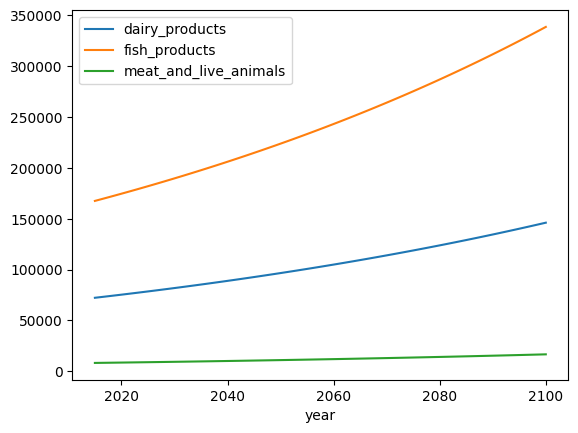

In [14]:
projected_df.plot(kind="line", x="year", y=projected_df.columns[1:])

### Now we need to allocate the exports to our livestock categories

In [15]:
livestock_categories = {
    "buffalo": "meat_and_live_animals",
    "cattle_dairy": "dairy_products",
    "cattle_nondairy": "meat_and_live_animals",
    "chickens": "meat_and_live_animals",
    "goats": "meat_and_live_animals",
    "horses": "meat_and_live_animals",
    "mules": "meat_and_live_animals",
    "pigs": "meat_and_live_animals",
    "sheep": "meat_and_live_animals",
}

In [16]:
pop_lvst_initial_df = uga_legacy_df[uga_legacy_df.columns[uga_legacy_df.columns.str.contains("pop_lvst_initial")]].copy()
pop_lvst_initial_df.head()

,pop_lvst_initial_chickens,pop_lvst_initial_goats,pop_lvst_initial_cattle_nondairy,pop_lvst_initial_horses,pop_lvst_initial_mules,pop_lvst_initial_cattle_dairy,pop_lvst_initial_sheep,pop_lvst_initial_pigs,pop_lvst_initial_buffalo
0,46039000.0,15312000.0,14031000.0,0.0,19220.0,14031000.0,3842000.0,3916000.0,0.0
1,46291000.0,15725000.0,14368000.0,0.0,19247.0,14368000.0,4198000.0,4037000.0,0.0
2,47578000.0,16034000.0,14189000.0,0.0,19277.0,14189000.0,4445000.0,4109000.0,0.0
3,48901000.0,16419000.0,14572000.0,0.0,19310.0,14572000.0,4584000.0,4245000.0,0.0
4,43121000.0,16945000.0,14785000.0,0.0,19343.0,14785000.0,4666000.0,4411000.0,0.0


In [17]:
# We will drop cattle_dairy since there is a direct match with dairy products
pop_lvst_initial_df = pop_lvst_initial_df.drop(columns=["pop_lvst_initial_cattle_dairy"])
pop_lvst_initial_df.head()

,pop_lvst_initial_chickens,pop_lvst_initial_goats,pop_lvst_initial_cattle_nondairy,pop_lvst_initial_horses,pop_lvst_initial_mules,pop_lvst_initial_sheep,pop_lvst_initial_pigs,pop_lvst_initial_buffalo
0,46039000.0,15312000.0,14031000.0,0.0,19220.0,3842000.0,3916000.0,0.0
1,46291000.0,15725000.0,14368000.0,0.0,19247.0,4198000.0,4037000.0,0.0
2,47578000.0,16034000.0,14189000.0,0.0,19277.0,4445000.0,4109000.0,0.0
3,48901000.0,16419000.0,14572000.0,0.0,19310.0,4584000.0,4245000.0,0.0
4,43121000.0,16945000.0,14785000.0,0.0,19343.0,4666000.0,4411000.0,0.0


In [18]:
shares_of_pop_lvst = pop_lvst_initial_df.div(pop_lvst_initial_df.sum(axis=1), axis=0)
shares_of_pop_lvst.head()

,pop_lvst_initial_chickens,pop_lvst_initial_goats,pop_lvst_initial_cattle_nondairy,pop_lvst_initial_horses,pop_lvst_initial_mules,pop_lvst_initial_sheep,pop_lvst_initial_pigs,pop_lvst_initial_buffalo
0,0.553625,0.184129,0.168725,0.0,0.000231,0.046201,0.047090,0.0
1,0.546928,0.185791,0.169758,0.0,0.000227,0.049599,0.047697,0.0
2,0.550835,0.185634,0.164273,0.0,0.000223,0.051462,0.047572,0.0
3,0.551057,0.185023,0.164209,0.0,0.000218,0.051656,0.047836,0.0
4,0.513667,0.201853,0.176122,0.0,0.000230,0.055582,0.052545,0.0


In [19]:
mean_shares_pop_lvst = shares_of_pop_lvst.mean()
mean_shares_pop_lvst

pop_lvst_initial_chickens           0.530717
pop_lvst_initial_goats              0.196030
pop_lvst_initial_cattle_nondairy    0.167134
pop_lvst_initial_horses             0.000000
pop_lvst_initial_mules              0.000215
pop_lvst_initial_sheep              0.054020
pop_lvst_initial_pigs               0.051885
pop_lvst_initial_buffalo            0.000000
dtype: float64

In [20]:
# use mean shares to allocate exports to livestock categories
final_usd_exports_df = projected_df[["year"]].copy()
for lvst_cat, export_cat in livestock_categories.items():
    if lvst_cat == "cattle_dairy":
        final_usd_exports_df[lvst_cat + "_exports_usd"] = projected_df[export_cat]
    else:
        final_usd_exports_df[lvst_cat + "_exports_usd"] = projected_df[export_cat] * mean_shares_pop_lvst["pop_lvst_initial_" + lvst_cat]

final_usd_exports_df.head()

,year,buffalo_exports_usd,cattle_dairy_exports_usd,cattle_nondairy_exports_usd,chickens_exports_usd,goats_exports_usd,horses_exports_usd,mules_exports_usd,pigs_exports_usd,sheep_exports_usd
0,2015,0.0,72272.877537,1380.417746,4383.368809,1619.076409,0.0,1.773026,428.534080,446.169303
1,2016,0.0,72873.578426,1391.891181,4419.801474,1632.533471,0.0,1.787763,432.095870,449.877670
2,2017,0.0,73479.272081,1403.459978,4456.536952,1646.102383,0.0,1.802622,435.687264,453.616858
3,2018,0.0,74090.000000,1415.124930,4493.577759,1659.784074,0.0,1.817604,439.308508,457.387125
4,2019,0.0,74705.804025,1426.886836,4530.926433,1673.579481,0.0,1.832712,442.959850,461.188729


In [21]:
final_usd_exports_df.tail()

,year,buffalo_exports_usd,cattle_dairy_exports_usd,cattle_nondairy_exports_usd,chickens_exports_usd,goats_exports_usd,horses_exports_usd,mules_exports_usd,pigs_exports_usd,sheep_exports_usd
81,2096,0.0,141302.566913,2698.890338,8570.037413,3165.498046,0.0,3.466489,837.838032,872.317112
82,2097,0.0,142477.012714,2721.322346,8641.267856,3191.808296,0.0,3.495301,844.801779,879.567435
83,2098,0.0,143661.220001,2743.940800,8713.090336,3218.337225,0.0,3.524352,851.823406,886.878019
84,2099,0.0,144855.269906,2766.747249,8785.509773,3245.086652,0.0,3.553645,858.903394,894.249365
85,2100,0.0,146059.244238,2789.743255,8858.531129,3272.058408,0.0,3.583182,866.042227,901.681979


In [22]:
# Validation
is_dairy_match = np.isclose(final_usd_exports_df["cattle_dairy_exports_usd"], projected_df["dairy_products"]).all()
print("cattle_dairy_exports_usd matches projected dairy_products:", is_dairy_match)

meat_exports_sum = final_usd_exports_df.drop(columns=["cattle_dairy_exports_usd", "year"]).sum(axis=1)
is_meat_match = np.isclose(meat_exports_sum, projected_df["meat_and_live_animals"]).all()
print("Sum of allocated meat_and_live_animals matches projected:", is_meat_match)

if not is_dairy_match:
    print("First mismatches (dairy):")
    print(final_usd_exports_df["cattle_dairy_exports_usd"].sub(projected_df["dairy_products"]).abs().nlargest(5))

if not is_meat_match:
    print("First mismatches (meat):")
    print(meat_exports_sum.sub(projected_df["meat_and_live_animals"]).abs().nlargest(5))

cattle_dairy_exports_usd matches projected dairy_products: True
Sum of allocated meat_and_live_animals matches projected: True


### Then, we need to convert the USD to livestock head counts

In [23]:
# Load FAOSTAT data
fao_lvst_df = pd.read_csv(os.path.join(LVST_DATA_DIR_PATH, "FAOSTAT_data_en_9-12-2025.csv"))
fao_lvst_df = fao_lvst_df.drop(columns=["Area", "Domain", "Year"])
fao_lvst_df.head()

,Element,Item,Unit,Value
0,Export quantity,Cattle,An,23500
1,Export value,Cattle,1000 USD,14270
2,Export quantity,Chickens,1000 An,4000
3,Export value,Chickens,1000 USD,7163
4,Export quantity,Goats,An,63000


In [24]:
# multiply by 1000 chickens export quantity
fao_lvst_df.iloc[2, -1] = fao_lvst_df.iloc[2, -1] * 1000
fao_lvst_df

,Element,Item,Unit,Value
0,Export quantity,Cattle,An,23500
1,Export value,Cattle,1000 USD,14270
2,Export quantity,Chickens,1000 An,4000000
3,Export value,Chickens,1000 USD,7163
4,Export quantity,Goats,An,63000
5,Export value,Goats,1000 USD,1806
6,Export quantity,Sheep,An,17200
7,Export value,Sheep,1000 USD,652
8,Export quantity,Swine / pigs,An,7800
9,Export value,Swine / pigs,1000 USD,398


In [25]:
# Drop Unit column
fao_lvst_df = fao_lvst_df.drop(columns=["Unit"])
fao_lvst_df.head()

,Element,Item,Value
0,Export quantity,Cattle,23500
1,Export value,Cattle,14270
2,Export quantity,Chickens,4000000
3,Export value,Chickens,7163
4,Export quantity,Goats,63000


In [26]:
# Add correct livestock category names
fao_to_ssp_lvst = [
    {"fao": "Cattle", "ssp": "cattle_nondairy"},
    {"fao": "Chickens", "ssp": "chickens"},
    {"fao": "Goats", "ssp": "goats"},
    {"fao": "Sheep", "ssp": "sheep"},
    {"fao": "Swine / pigs", "ssp": "pigs"}
]

fao_to_ssp_lvst_df = pd.DataFrame(fao_to_ssp_lvst)
fao_to_ssp_lvst_df

,fao,ssp
0,Cattle,cattle_nondairy
1,Chickens,chickens
2,Goats,goats
3,Sheep,sheep
4,Swine / pigs,pigs


In [27]:
fao_lvst_df = fao_lvst_df.merge(fao_to_ssp_lvst_df, left_on="Item", right_on="fao", how="left").drop(columns=["fao", "Item"])
fao_lvst_df

,Element,Value,ssp
0,Export quantity,23500,cattle_nondairy
1,Export value,14270,cattle_nondairy
2,Export quantity,4000000,chickens
3,Export value,7163,chickens
4,Export quantity,63000,goats
5,Export value,1806,goats
6,Export quantity,17200,sheep
7,Export value,652,sheep
8,Export quantity,7800,pigs
9,Export value,398,pigs


In [28]:
# pivot to have Element as columns
fao_lvst_df = fao_lvst_df.pivot(index="ssp", columns="Element", values="Value").reset_index()
fao_lvst_df.columns.name = None
fao_lvst_df.head()

,ssp,Export quantity,Export value
0,cattle_nondairy,23500,14270
1,chickens,4000000,7163
2,goats,63000,1806
3,pigs,7800,398
4,sheep,17200,652


In [29]:
fao_lvst_df["conversion_factor_usd_per_head"] = fao_lvst_df["Export quantity"] / fao_lvst_df["Export value"]
fao_lvst_df = fao_lvst_df.rename(columns={"ssp": "lvst_category"})
fao_lvst_df.head()

,lvst_category,Export quantity,Export value,conversion_factor_usd_per_head
0,cattle_nondairy,23500,14270,1.646811
1,chickens,4000000,7163,558.425241
2,goats,63000,1806,34.883721
3,pigs,7800,398,19.597990
4,sheep,17200,652,26.380368


In [30]:
# Add missing livestock catetgories
remaining_lvst_cats_dict ={
    "lvst_category": ["cattle_dairy", "buffalo", "horses", "mules"],
    "Export quantity": [np.nan, np.nan, np.nan, np.nan],
    "Export value": [np.nan, np.nan, np.nan, np.nan],
    "conversion_factor_usd_per_head": [1.646811, 0, 0, 0.5031446540880503]
}

remaining_lvst_cats_df = pd.DataFrame(remaining_lvst_cats_dict)
remaining_lvst_cats_df

,lvst_category,Export quantity,Export value,conversion_factor_usd_per_head
0,cattle_dairy,NaN,NaN,1.646811
1,buffalo,NaN,NaN,0.000000
2,horses,NaN,NaN,0.000000
3,mules,NaN,NaN,0.503145


In [31]:
# concat with fao_lvst_df
fao_lvst_df = pd.concat([fao_lvst_df, remaining_lvst_cats_df], ignore_index=True)
fao_lvst_df

,lvst_category,Export quantity,Export value,conversion_factor_usd_per_head
0,cattle_nondairy,23500.0,14270.0,1.646811
1,chickens,4000000.0,7163.0,558.425241
2,goats,63000.0,1806.0,34.883721
3,pigs,7800.0,398.0,19.597990
4,sheep,17200.0,652.0,26.380368
5,cattle_dairy,NaN,NaN,1.646811
6,buffalo,NaN,NaN,0.000000
7,horses,NaN,NaN,0.000000
8,mules,NaN,NaN,0.503145


In [32]:
# Set index to Item for easier lookup
fao_lvst_df = fao_lvst_df.set_index("lvst_category")
fao_lvst_df.head()

,Export quantity,Export value,conversion_factor_usd_per_head
lvst_category,,,
cattle_nondairy,23500.0,14270.0,1.646811
chickens,4000000.0,7163.0,558.425241
goats,63000.0,1806.0,34.883721
pigs,7800.0,398.0,19.597990
sheep,17200.0,652.0,26.380368


In [33]:
final_usd_exports_df.head()

,year,buffalo_exports_usd,cattle_dairy_exports_usd,cattle_nondairy_exports_usd,chickens_exports_usd,goats_exports_usd,horses_exports_usd,mules_exports_usd,pigs_exports_usd,sheep_exports_usd
0,2015,0.0,72272.877537,1380.417746,4383.368809,1619.076409,0.0,1.773026,428.534080,446.169303
1,2016,0.0,72873.578426,1391.891181,4419.801474,1632.533471,0.0,1.787763,432.095870,449.877670
2,2017,0.0,73479.272081,1403.459978,4456.536952,1646.102383,0.0,1.802622,435.687264,453.616858
3,2018,0.0,74090.000000,1415.124930,4493.577759,1659.784074,0.0,1.817604,439.308508,457.387125
4,2019,0.0,74705.804025,1426.886836,4530.926433,1673.579481,0.0,1.832712,442.959850,461.188729


In [34]:
final_headcount_exports_df = pd.DataFrame()
for lvst_cat in livestock_categories.keys():
    # Get the series from usd exports
    usd_series = final_usd_exports_df[lvst_cat + "_exports_usd"]
    # Get the conversion factor from fao_lvst_df
    conv_factor = fao_lvst_df.loc[lvst_cat, "conversion_factor_usd_per_head"]
    # Calculate headcount series
    final_headcount_exports_df["exports_lvst_" + lvst_cat] = usd_series * conv_factor


# Add year column
final_headcount_exports_df["year"] = final_usd_exports_df["year"]
final_headcount_exports_df.head()    

,exports_lvst_buffalo,exports_lvst_cattle_dairy,exports_lvst_cattle_nondairy,exports_lvst_chickens,exports_lvst_goats,exports_lvst_horses,exports_lvst_mules,exports_lvst_pigs,exports_lvst_sheep,year
0,0.0,119019.769730,2273.287808,2.447784e+06,56479.409611,0.0,0.892089,8398.406589,11770.110457,2015
1,0.0,120009.010562,2292.182393,2.468129e+06,56948.842028,0.0,0.899503,8468.210511,11867.938523,2016
2,0.0,121006.473536,2311.234021,2.488643e+06,57422.176164,0.0,0.906980,8538.594613,11966.579693,2017
3,0.0,122012.226990,2330.443998,2.509327e+06,57899.444448,0.0,0.914518,8609.563717,12066.040726,2018
4,0.0,123026.339832,2349.813640,2.530184e+06,58380.679580,0.0,0.922119,8681.122686,12166.328436,2019


### Validation

<Axes: xlabel='year'>

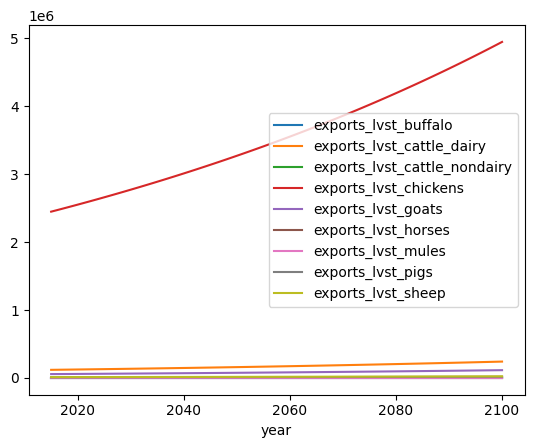

In [35]:
final_headcount_exports_df.plot(kind="line", x="year", y=final_headcount_exports_df.drop(columns=["year"]).columns)

In [36]:
# Create again pop_lvst_initial_df so we include cattle_dairy
pop_lvst_initial_df = uga_legacy_df[uga_legacy_df.columns[uga_legacy_df.columns.str.contains("pop_lvst_initial")]].copy()
pop_lvst_initial_df.head()

,pop_lvst_initial_chickens,pop_lvst_initial_goats,pop_lvst_initial_cattle_nondairy,pop_lvst_initial_horses,pop_lvst_initial_mules,pop_lvst_initial_cattle_dairy,pop_lvst_initial_sheep,pop_lvst_initial_pigs,pop_lvst_initial_buffalo
0,46039000.0,15312000.0,14031000.0,0.0,19220.0,14031000.0,3842000.0,3916000.0,0.0
1,46291000.0,15725000.0,14368000.0,0.0,19247.0,14368000.0,4198000.0,4037000.0,0.0
2,47578000.0,16034000.0,14189000.0,0.0,19277.0,14189000.0,4445000.0,4109000.0,0.0
3,48901000.0,16419000.0,14572000.0,0.0,19310.0,14572000.0,4584000.0,4245000.0,0.0
4,43121000.0,16945000.0,14785000.0,0.0,19343.0,14785000.0,4666000.0,4411000.0,0.0


In [37]:
for lvst_cat in livestock_categories.keys():
    export_headcount = final_headcount_exports_df["exports_lvst_" + lvst_cat]
    initial_pop = pop_lvst_initial_df["pop_lvst_initial_" + lvst_cat][:len(export_headcount)].reset_index(drop=True)
    exceeded = export_headcount > initial_pop
    for year, is_exceeded in zip(final_headcount_exports_df["year"], exceeded):
        if is_exceeded:
            print(f"Warning: Exports for {lvst_cat} exceed initial population in year {year}.")

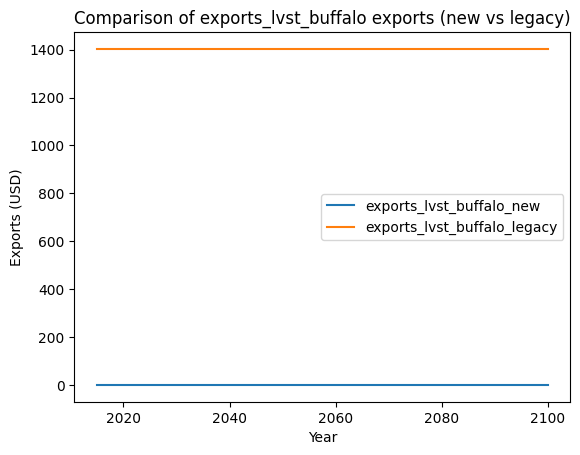

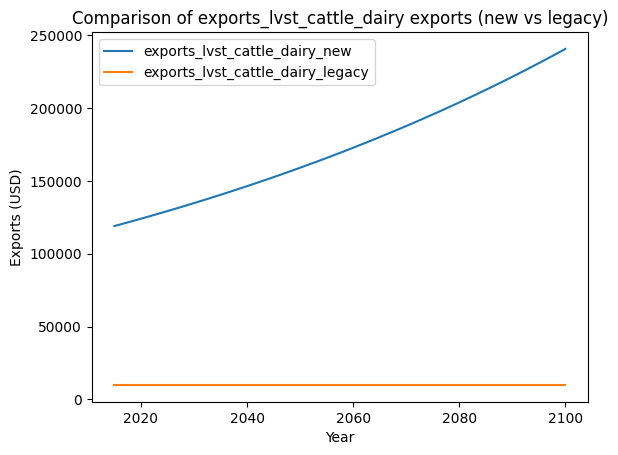

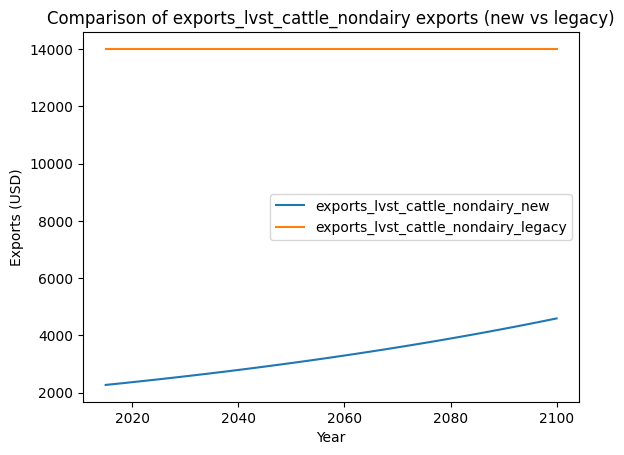

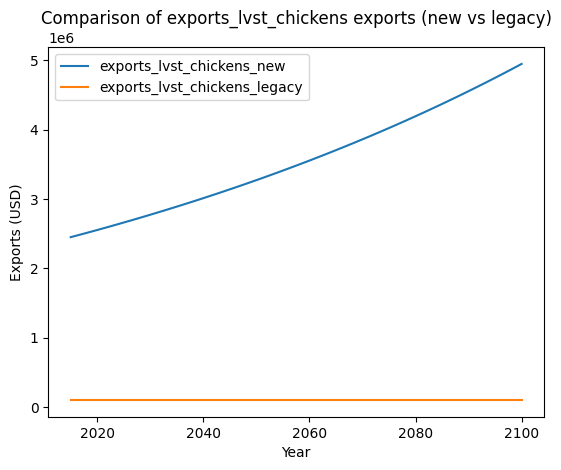

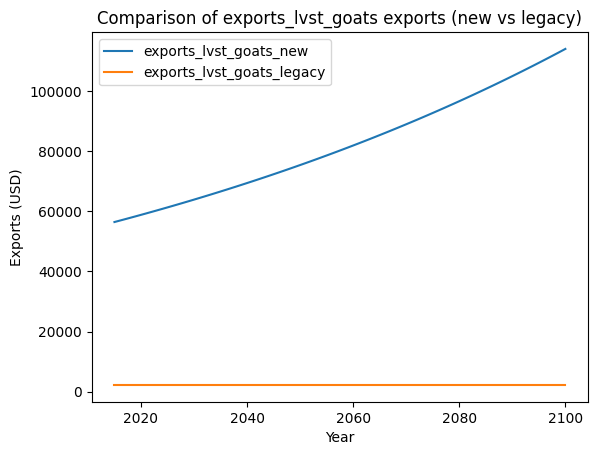

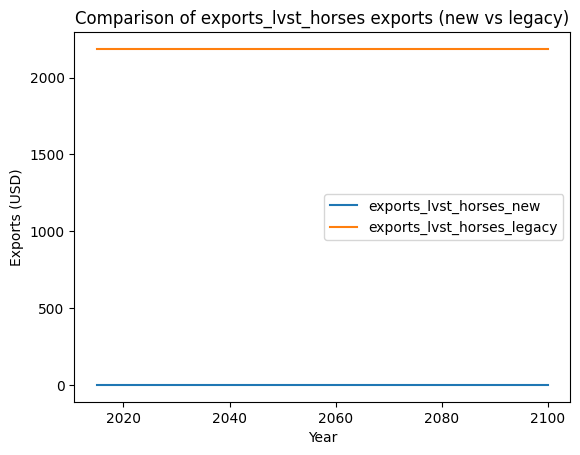

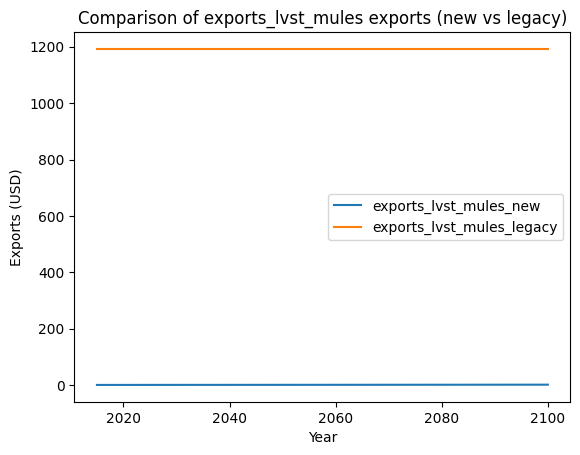

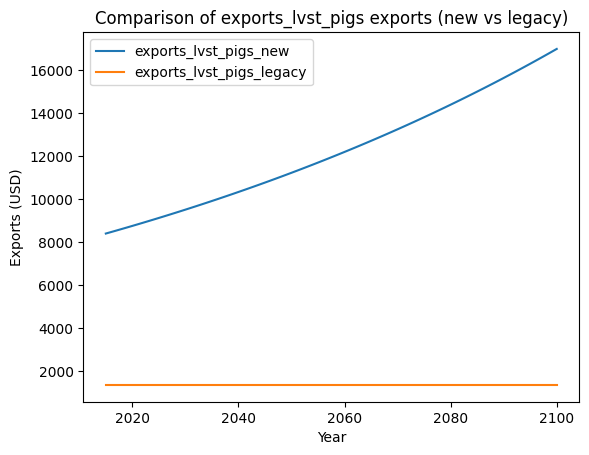

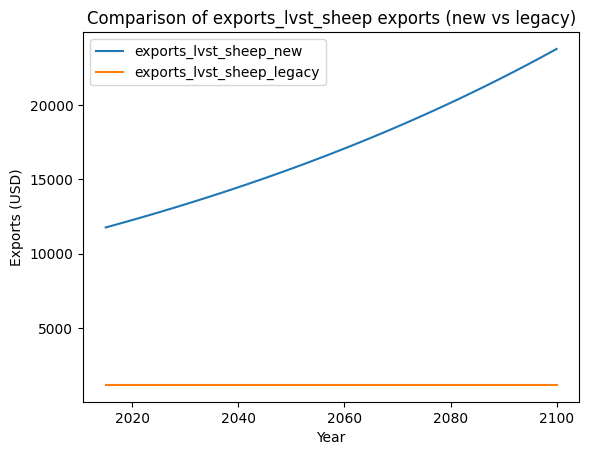

In [38]:
# Compare with legacy variables
for export_cat in final_headcount_exports_df.columns:

    if export_cat == "year":
        continue
    
    plt.plot(final_headcount_exports_df["year"], final_headcount_exports_df[export_cat], label=f"{export_cat}_new")
    plt.plot(uga_legacy_df["year"], uga_legacy_df[export_cat], label=f"{export_cat}_legacy")
    plt.legend()
    plt.title(f"Comparison of {export_cat} exports (new vs legacy)")
    plt.xlabel("Year")
    plt.ylabel("Exports (USD)")
    plt.show()


In [39]:
# move year to first column
final_headcount_exports_df = final_headcount_exports_df[["year"] + [col for col in final_headcount_exports_df.columns if col != "year"]]
# save to csv
final_headcount_exports_df.to_csv(os.path.join(OUTPUT_DATA_DIR_PATH, "exports_lvst.csv"), index=False)